<center>

***
<font size="4">
Demix, Beats, and Onsets<br>
</font>
<br>
<font size="3">
19 April 2026 <br>
Juan Ignacio Mendoza Garay
<font size="3">

***
</center>

Dependencies:
* [demucs](https://github.com/adefossez/demucs)
* [ffmpeg](https://www.ffmpeg.org/download.html): Its directory should be in the system's path variable.
* [madmom](https://github.com/CPJKU/madmom): If having problem "ModuleNotFoundError: No module named 'Cython'", install from source with command "pip install git+https://github.com/CPJKU/madmom" in terminal.

Tested with:
* Windows 11
* [Python](https://www.python.org/downloads/) 3.8.10
* [numpy](https://numpy.org/doc/stable/release/1.19.5-notes.html) 1.19.5
* [matplotlib](https://matplotlib.org/3.6.0/index.html) 3.6
* [pytorch](https://pytorch.org/get-started/previous-versions/) 2.4.1+cpu

Installation:
* It is recommended to use a virtual environment, for example [venv](https://docs.python.org/3/library/venv.html). To do so, [install the desired version of Python](https://www.python.org/downloads/) (if not already installed), then use  command  "py -X.x -m venv YY" (or python instead of py) in terminal where X.x is the desired version of Python and YY is the path of the virtual environment (it will be created). 

Instructions:
* Edit the values indicated with an arrow like this: <---
* Comment/uncomment or change values as suggested by the comments.
* Run the program, close your eyes and hope for the best.

***

In [1]:
import os
import numpy as np

from matplotlib import pyplot as plt
from scipy.interpolate import CubicSpline

import demucs.separate
from madmom.audio.signal import Signal
from madmom.features.downbeats import RNNDownBeatProcessor
from madmom.features.downbeats import DBNDownBeatTrackingProcessor
from madmom.features.onsets import OnsetPeakPickingProcessor

***
### Setup 
#### Set paths and parameters

In [ ]:
user_path = "C:/Users/Kvasir/" # <---

audio_dir = user_path + "Music/"                     # <--- folder of origin audio file
fn = 'alanajordan-lucky-you-with-vocals-364282.mp3'  # <--- audio file name
# source: https://pixabay.com/music/funk-lucky-you-with-vocals-364282/

out_path = user_path + "Documents/source_sep_rhythm" # <--- folder to save files

trim = [9,19] # <--- [start,end] in seconds, or None

>
#### Process paths and trim

In [3]:
ffn_in = os.path.join(audio_dir, fn)
bname_split = os.path.splitext(os.path.basename(fn))
if trim:
    ffn_orig = ffn_in
    lbl = f'_{trim[0]}-{trim[1]}'
    bname_lbl = bname_split[0] + lbl + bname_split[1]
    ffn_trimmed = os.path.join(out_path, bname_lbl)
    bname_split = os.path.splitext(bname_lbl)
    if os.path.exists(ffn_trimmed):
        print('Trimmed file already exists. Process aborted.')
    else:
        trim_cmd = f' -ss {trim[0]} -to {trim[1]}'
        ! ffmpeg -y -loglevel error -i {ffn_orig}{trim_cmd} -acodec copy {ffn_trimmed}
    ffn_in = ffn_trimmed
os.chdir(out_path)

***
### Demix
#### Source separation with `demucs` library.

In [4]:
%%capture
# %%capture hides printed output

# model_name = "mdx_q" # <--- fastest ?
# model_name = "mdx_extra_q" # <--- fast
# model_name = "mdx" # <--- good 
# model_name = "mdx_extra" # <--- gooder
# model_name = "hdemucs_mmi" # <--- better 
# model_name = "htdemucs" # <--- best
model_name = "htdemucs_ft" # <--- bestest ?

sep_dir = os.path.join(out_path, 'separated', model_name, bname_split[0])
if os.path.isdir(sep_dir): print(f'Already demixed with {model_name}')
else: demucs.separate.main(["-n", model_name, ffn_in])

***
### Beat & Onset identification 
#### Identification of beats, downbeats, and onsets with `madmom` library.


In [5]:
%%capture
# %%capture hides printed output

voice_list = ['bass','drums'] # <--- select demixed voices
dbpar = {
    'beats_per_bar':4,  # <--- beats per bar
    'threshold':0.14,   # <--- downbeat threshold
    'fps':100
}
os_pk_thrsh = 0.5       # <--- onset threshold
osmeth = 'CNN'          # <--- onset detection method

# Onset detection methods:
    # 'RNN', 'CNN'
    # 'superflux', 'complex_flux', 'high_frequency_content',
    # 'spectral_diff', 'spectral_flux', 'modified_kullback_leibler',
    # 'phase_deviation', 'weighted_phase_deviation',
    # 'normalized_weighted_phase_deviation', 'complex_domain',
    # 'rectified_complex_domain'

if osmeth == 'CNN':
    from madmom.features.onsets import CNNOnsetProcessor
    osproc = CNNOnsetProcessor
elif osmeth == 'RNN':
    from madmom.features.onsets import RNNOnsetProcessor
    osproc = RNNOnsetProcessor
else:
    from madmom.features.onsets import SpectralOnsetProcessor
    osproc = SpectralOnsetProcessor(onset_method=osmeth)
n_voices = len(voice_list)
data = {}
for sel_voice in voice_list:
    data[sel_voice] = {}
    ffn_t = os.path.join(sep_dir, sel_voice + '.wav')
    
    data[sel_voice]['signal'] = {}
    sig = Signal(ffn_t, num_channels=1)
    data[sel_voice]['signal']['sig'] = sig
    data[sel_voice]['signal']['sr'] = sig.sample_rate

    data[sel_voice]['beat'] = {}
    beat_score = RNNDownBeatProcessor()(sig)
    data[sel_voice]['beat']['score'] = beat_score
    data[sel_voice]['beat']['beats'] = DBNDownBeatTrackingProcessor(**dbpar)(beat_score)

    data[sel_voice]['onset'] = {}
    os_score = osproc()(sig)
    os_score = os_score/max(os_score)
    data[sel_voice]['onset']['score'] = os_score
    onsets = OnsetPeakPickingProcessor(threshold=os_pk_thrsh)(os_score)
    data[sel_voice]['onset']['onsets'] = onsets

>
#### Plot beats, downbeats, and onsets

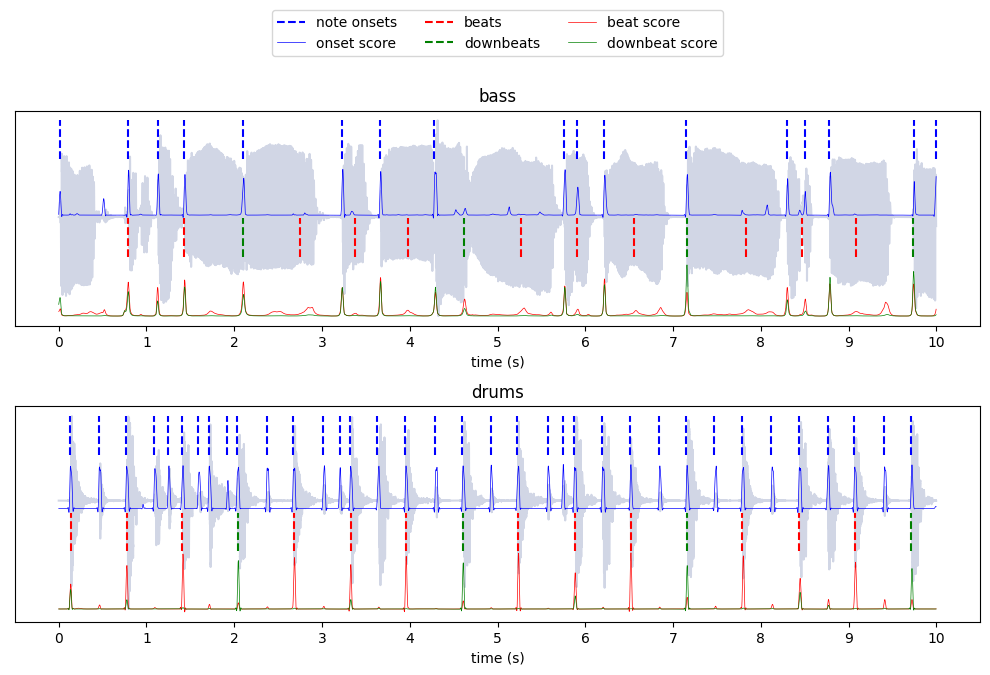

In [6]:
oslog = False # <--- visualise onset scores in logarithmic scale

fig, axs = plt.subplots(n_voices,figsize=(10,n_voices*3.5))
for i, (sel_voice,v) in enumerate(data.items()):

    # signal:
    sig = data[sel_voice]['signal']['sig'] 
    min_sig = float(min(sig))
    max_sig = float(max(sig))
    sig_rs =  (sig - min_sig)/(max_sig-min_sig)
    axs[i].plot(sig_rs, color=(0.1, 0.2, 0.5, 0.2))
    
    len_sig = len(sig)
    sr = data[sel_voice]['signal']['sr']

    # onsets:
    onsets = data[sel_voice]['onset']['onsets'] * sr
    log_lbl = ''
    if oslog: log_lbl = ' (log10)'
    axs[i].vlines(
        onsets, 0.8, 1, colors='b', linewidth=1.5, linestyle='dashed',
        label='note onsets' + log_lbl 
    )

    # onset score:
    oss = data[sel_voice]['onset']['score']
    if oslog:
        oss = np.log10(oss)
    len_oss = len(oss)
    t_os_rescaled = np.linspace(0, len_oss-1, num=int(len_sig))
    t_oss = np.linspace(0, len_oss-1, len_oss)
    oss_rs = CubicSpline(t_oss, oss)(t_os_rescaled)
    oss_rs -= min(oss_rs)
    oss_rs = 0.25 * oss_rs/max(oss_rs) + 0.5
    axs[i].plot(oss_rs, linewidth=0.5, color='b', label='onset score')

    # beats and downbeats:
    ones = data[sel_voice]['beat']['ones'] = []
    other = data[sel_voice]['beat']['other'] = []
    for b in v['beat']['beats']:
        if b[1] == 1: ones.append(b[0] * sr)
        else: other.append(b[0] * sr)
    axs[i].vlines(
        other, 0.3, 0.5, linewidth=1.5, linestyle='dashed', colors='r', label='beats'
        )
    axs[i].vlines(
        ones, 0.3, 0.5, linewidth=1.5, linestyle='dashed', colors='g', label='downbeats'
        )

    # beats and downbeats scores (A.K.A. activations):
    bs = data[sel_voice]['beat']['score']
    bs -= np.min(bs)
    bs = 0.25 * bs/np.max(bs)
    len_beat_score = len(bs)
    t_bs_rescaled = np.linspace(0, len_oss-1, num=int(len_sig))

    t_beat_score = np.linspace(0, len_beat_score-1,  len_beat_score)
    for i_s,s in enumerate(bs.T):
        bs_rs = CubicSpline(t_beat_score, s)(t_bs_rescaled)
        if i_s == 0:
            axs[i].plot(bs_rs, linewidth=0.5, color='r', label='beat score')
        else:
            axs[i].plot(bs_rs, linewidth=0.5, color='g', label='downbeat score')

    if i == 0:
        axs[i].legend(loc='upper center', bbox_to_anchor=(0, 0, 1, 1.5), ncols=3)
    axs[i].set_title(sel_voice)
    
    if len_sig > sr:
        if trim:
            xtl = list(range(trim[-1]-trim[0]+1))
        else:
            xtl = list(range(np.ceil(len_sig/sr)))
        xt = [v*sr for v in xtl]
    else:
        xt = [v for v in axs[i].get_xticks() if (v >= 0) and (v < len_sig)]
        xtl = [v/sr for v in xt]
    axs[i].set_xticks(xt)
    axs[i].set_xticklabels([f'{v:.2g}' for v in xtl])
    axs[i].set_xlabel('time (s)')
    axs[i].set_yticks([])
plt.tight_layout()

Notice that:
* The first beat is correctly not recognised as a downbeat (one or three).
* Not all onsets are correctly recognised, as the correct recognition depends on the method's parameters, which must be fine-tuned for each audio example. This includes the training for methods involving neural networks (CNN and RNN). However, the scores produced (called "activations" in the documentation for `madmom`) have less parameters and thus they may be a better choice for modelling.